## Implementing a GNN using the PyTorch Geometric library

In [ ]:
!pip install torch torchvision torchaudio torch-geometric networkx matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.4 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn


from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import NNConv, global_add_pool

import numpy as np

In [ ]:
dset = QM9('.')
len(dset)

Extracting ./raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


130831

### QM9 Dataset

The **QM9 dataset** is a widely-used benchmark dataset in computational chemistry and machine learning for molecular property prediction. It contains quantum mechanical calculations for 134,000+ small organic molecules composed of hydrogen (H), carbon (C), nitrogen (N), oxygen (O), and fluorine (F). The dataset is a valuable resource for training models to predict quantum chemical properties of molecules.

---

### Data Structure in QM9

Each molecule in the QM9 dataset is represented as a **graph**, where:
- **Nodes** represent atoms (H, C, N, O, F).
- **Edges** represent bonds between the atoms.

In **PyTorch Geometric**, the dataset is stored in a `Data` object, which contains the following attributes:

| **Attribute**   | **Shape**             | **Description**                                                                                         |
|------------------|-----------------------|---------------------------------------------------------------------------------------------------------|
| `x`             | `[num_atoms, num_features]` | Node feature matrix describing properties of each atom.                                                |
| `edge_index`    | `[2, num_edges]`      | Connectivity matrix defining which atoms are connected by bonds (source and target nodes).              |
| `edge_attr`     | `[num_edges, num_features]` | Edge feature matrix describing properties of the bonds (e.g., bond type, aromaticity, etc.).           |
| `y`             | `[1, num_targets]`    | Molecular property vector containing 19 quantum mechanical properties for the molecule.                |
| `pos`           | `[num_atoms, 3]`      | 3D Cartesian coordinates (x, y, z) of each atom in the molecule.                                       |
| `z`             | `[num_atoms]`         | Atomic numbers of the atoms (e.g., 1 for H, 6 for C).                                                  |
| `idx`           | `[1]`                 | Index of the molecule in the dataset.                                                                  |
| `name`          | `string`              | Name of the molecule (e.g., `gdb_128`), corresponding to its GDB identifier.                           |

---




In [ ]:
data = dset[124]
data

Data(x=[13, 11], edge_index=[2, 24], edge_attr=[24, 4], y=[1, 19], pos=[13, 3], idx=[1], name='gdb_128', z=[13])

### Details of Each Attribute

#### `x` (Node Features)
- The `x` matrix contains features describing each atom in the molecule.
- Example features may include:
  - **Atomic number (Z):** Numerical identifier for the atom (e.g., H = 1, C = 6).
  - **Hybridization state:** sp, sp2, sp3, etc.
  - **Formal charge:** Charge on the atom.
  - **Number of valence electrons:** Total electrons available for bonding.

#### `edge_index` (Edge Connectivity)
- This is a sparse matrix in COO (Coordinate List) format that defines the connections (bonds) between atoms.
  - The first row contains the **source nodes** of the edges.
  - The second row contains the **target nodes** of the edges.

#### `edge_attr` (Edge Features)
- This matrix contains features describing each bond in the molecule.
- Example features may include:
  - **Bond type:** Single, double, triple, aromatic.
  - **Bond length:** Distance between the connected atoms.
  - **Aromaticity:** Whether the bond is part of an aromatic ring.

#### `y` (Molecular Properties)
- The `y` attribute is a vector of 19 quantum mechanical properties for the molecule, computed using **Density Functional Theory (DFT)**.
- Examples of these properties include:
  - **HOMO:** Energy of the Highest Occupied Molecular Orbital.
  - **LUMO:** Energy of the Lowest Unoccupied Molecular Orbital.
  - **Dipole moment:** Measure of the separation of positive and negative charges in the molecule.
  - **Atomization energy:** Energy required to break a molecule into individual atoms.
  - **Polarizability:** Molecule's ability to polarize in an electric field.

#### `pos` (3D Atomic Positions)
- The `pos` attribute contains the 3D Cartesian coordinates of each atom in the molecule.
- These are crucial for tasks involving spatial and geometric properties, such as force fields or molecular dynamics.

#### `z` (Atomic Numbers)
- The `z` attribute stores the atomic numbers of the atoms in the molecule.

| **Atomic Number (Z)** | **Element** | **Symbol** |
|------------------------|-------------|------------|
| 1                      | Hydrogen    | H          |
| 6                      | Carbon      | C          |
| 7                      | Nitrogen    | N          |
| 8                      | Oxygen      | O          |
| 9                      | Fluorine    | F          |

#### `idx` (Molecule Index)
- This is the unique index of the molecule in the dataset, useful for tracking or referencing specific molecules.

#### `name` (Molecule Name)
- The name corresponds to the GDB identifier of the molecule (e.g., `gdb_128` this is ethanol.).

---

In [ ]:
# Lets visualize a few samples
import networkx as nx
from torch_geometric.utils import to_networkx

# Convert the PyTorch Geometric graph to a NetworkX graph
G = to_networkx(data, node_attrs=['x'], edge_attrs=None)

# Inspect the graph
print(G.nodes(data=True))
print(G.edges(data=True))



[(0, {'x': [0.0, 1.0, 0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 0.0, 0.0, 3.0]}), (1, {'x': [0.0, 1.0, 0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 0.0, 0.0, 2.0]}), (2, {'x': [0.0, 1.0, 0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 0.0, 0.0, 2.0]}), (3, {'x': [0.0, 1.0, 0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 0.0, 0.0, 1.0]}), (4, {'x': [0.0, 0.0, 0.0, 1.0, 0.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0]}), (5, {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}), (6, {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}), (7, {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}), (8, {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}), (9, {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}), (10, {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}), (11, {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}), (12, {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]})]
[(0, 1, {}), (0, 5, {}), (0, 6, {}), (0, 7, {}), (1, 0, {}), (1, 2, {}), (1, 8, {}), (1, 9, {}), (2

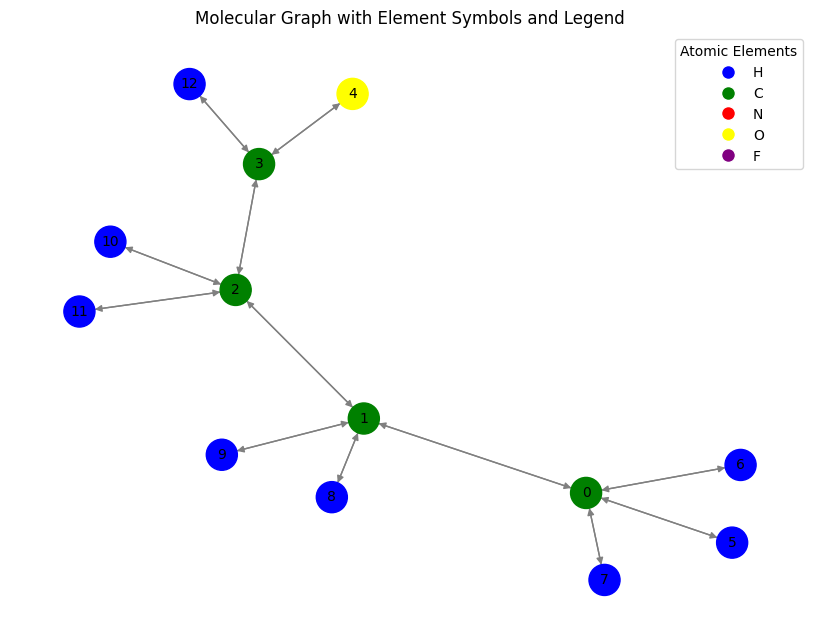

In [ ]:
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import networkx as nx

# Mapping atomic numbers to elements and colors
atomic_number_to_element = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F'}
atomic_number_to_color = {1: 'blue', 6: 'green', 7: 'red', 8: 'yellow', 9: 'purple'}

# Convert PyTorch Geometric graph to NetworkX
G = to_networkx(data)

# Extract atomic numbers and corresponding elements/colors
atomic_numbers = data.x[:, 5].tolist()  # Assuming column 5 contains atomic numbers
elements = [atomic_number_to_element[int(z)] for z in atomic_numbers]
node_colors = [atomic_number_to_color[int(z)] for z in atomic_numbers]

# Create a legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=atomic_number_to_element[element])
    for element, color in atomic_number_to_color.items()
]

# Node labels using element symbols
node_labels = {i: elements[i] for i in range(len(elements))}

# Plot the graph
plt.figure(figsize=(8, 6))
nx.draw(
    G,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=500,
    font_size=10,
)

# Add the legend
plt.legend(handles=legend_elements, loc='best', title="Atomic Elements")
plt.title("Molecular Graph with Element Symbols and Legend")
plt.show()


In [ ]:
# New information can be added as

data.new_attribute = torch.tensor([1, 2, 3])
data

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5], new_attribute=[3])

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
data.to(device)
data.new_attribute.is_cuda

True

In [ ]:
class ExampleNet(torch.nn.Module):
    def __init__(self,num_node_features,num_edge_features):
        super().__init__()
        conv1_net = nn.Sequential(nn.Linear(num_edge_features, 32),
                                  nn.ReLU(),
                                  nn.Linear(32, num_node_features*32))
        conv2_net = nn.Sequential(nn.Linear(num_edge_features,32),
                                  nn.ReLU(),
                                  nn.Linear(32, 32*16))
        self.conv1 = NNConv(num_node_features, 32, conv1_net)
        self.conv2 = NNConv(32, 16, conv2_net)
        self.fc_1 = nn.Linear(16, 32)
        self.out = nn.Linear(32, 1)

    def forward(self, data):
        batch, x, edge_index, edge_attr=data.batch, data.x, data.edge_index, data.edge_attr
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = global_add_pool(x,batch)
        x = F.relu(self.fc_1(x))
        output = self.out(x)
        return output

In [ ]:
from torch.utils.data import random_split


train_set, valid_set, test_set = random_split(dset,[110000, 10831, 10000])

trainloader = DataLoader(train_set, batch_size=32, shuffle=True)
validloader = DataLoader(valid_set, batch_size=32, shuffle=True)
testloader = DataLoader(test_set, batch_size=32, shuffle=True)

In [ ]:
qm9_node_feats, qm9_edge_feats = 11, 4
epochs = 4
net = ExampleNet(qm9_node_feats, qm9_edge_feats)

optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
epochs = 4
target_idx = 1 # index position of the polarizability label

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net.to(device)

ExampleNet(
  (conv1): NNConv(11, 32, aggr=add, nn=Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=352, bias=True)
  ))
  (conv2): NNConv(32, 16, aggr=add, nn=Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=512, bias=True)
  ))
  (fc_1): Linear(in_features=16, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
for total_epochs in range(epochs):

    epoch_loss = 0
    total_graphs = 0
    net.train()
    for batch in trainloader:
        batch.to(device)
        optimizer.zero_grad()
        output = net(batch)
        loss = F.mse_loss(output, batch.y[:, target_idx].unsqueeze(1))
        loss.backward()
        epoch_loss += loss.item()
        total_graphs += batch.num_graphs
        optimizer.step()

    train_avg_loss = epoch_loss / total_graphs
    val_loss = 0
    total_graphs = 0
    net.eval()
    for batch in validloader:
        batch.to(device)
        output = net(batch)
        loss = F.mse_loss(output,batch.y[:, target_idx].unsqueeze(1))
        val_loss += loss.item()
        total_graphs += batch.num_graphs
    val_avg_loss = val_loss / total_graphs


    print(f"Epochs: {total_epochs} | epoch avg. loss: {train_avg_loss:.2f} | validation avg. loss: {val_avg_loss:.2f}")

Epochs: 0 | epoch avg. loss: 0.42 | validation avg. loss: 0.15
Epochs: 1 | epoch avg. loss: 0.14 | validation avg. loss: 0.14
Epochs: 2 | epoch avg. loss: 0.11 | validation avg. loss: 0.08
Epochs: 3 | epoch avg. loss: 0.10 | validation avg. loss: 0.19


In [ ]:
net.eval()
predictions = []
real = []

for batch in testloader:

    output = net(batch.to(device))
    predictions.append(output.detach().cpu().numpy())
    real.append(batch.y[:, target_idx].detach().cpu().numpy())

predictions = np.concatenate(predictions)
real = np.concatenate(real)

Text(0.5, 0, 'Isotropic polarizability')

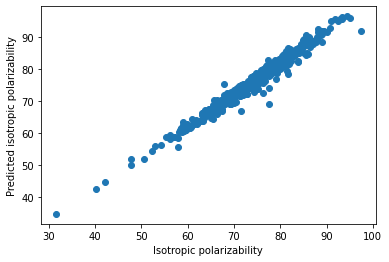

In [ ]:
import matplotlib.pyplot as plt


plt.scatter(real[:500],predictions[:500])
plt.ylabel('Predicted isotropic polarizability')
plt.xlabel('Isotropic polarizability')
#plt.savefig('figures/18_12.png', dpi=300)

### Pointers to advanced graph neural network literature